# EDA Template II

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Titanic-Dataset.csv')

## Quality Check
Age: impute with median grouped by Pclass + Sex (better than global median)

In [ ]:
df['Age'] = df.groupby(['Pclass','Sex']).transform(lambda x:x.fillna(x.median()))

Cabin: Too sparse to impute, turn into binary signal

In [2]:
df['Has Cabin'] = df['Cabin'].notnull().astype(int)
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].fillna('Unknown')

Embarked: Only 2, fill with mode

In [3]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Drop noise columns like passengerId, ticker, cabin

In [5]:
df.drop(columns=['PassengerId', 'Cabin', 'Ticket'], inplace=True)

## FEATURE ENGINEERING

Names are given titles so we seperate them

In [6]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

Seperate family relations are combined in one Family, then useless columns are deleted

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.drop(columns=['Name', 'SibSp', 'Parch'], inplace=True)

## DISTRIBUTION CHECK

In [10]:
print(df['Fare'].skew())
print(df['Age'].skew())
df['Fare_Log'] = np.log1p(df['Fare'])

4.787316519674893
0.38910778230082704


## TARGET VALUE CHECK

In [11]:
print(df['Survived'].value_counts(normalize=True))

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


## VISUALIZATIONS

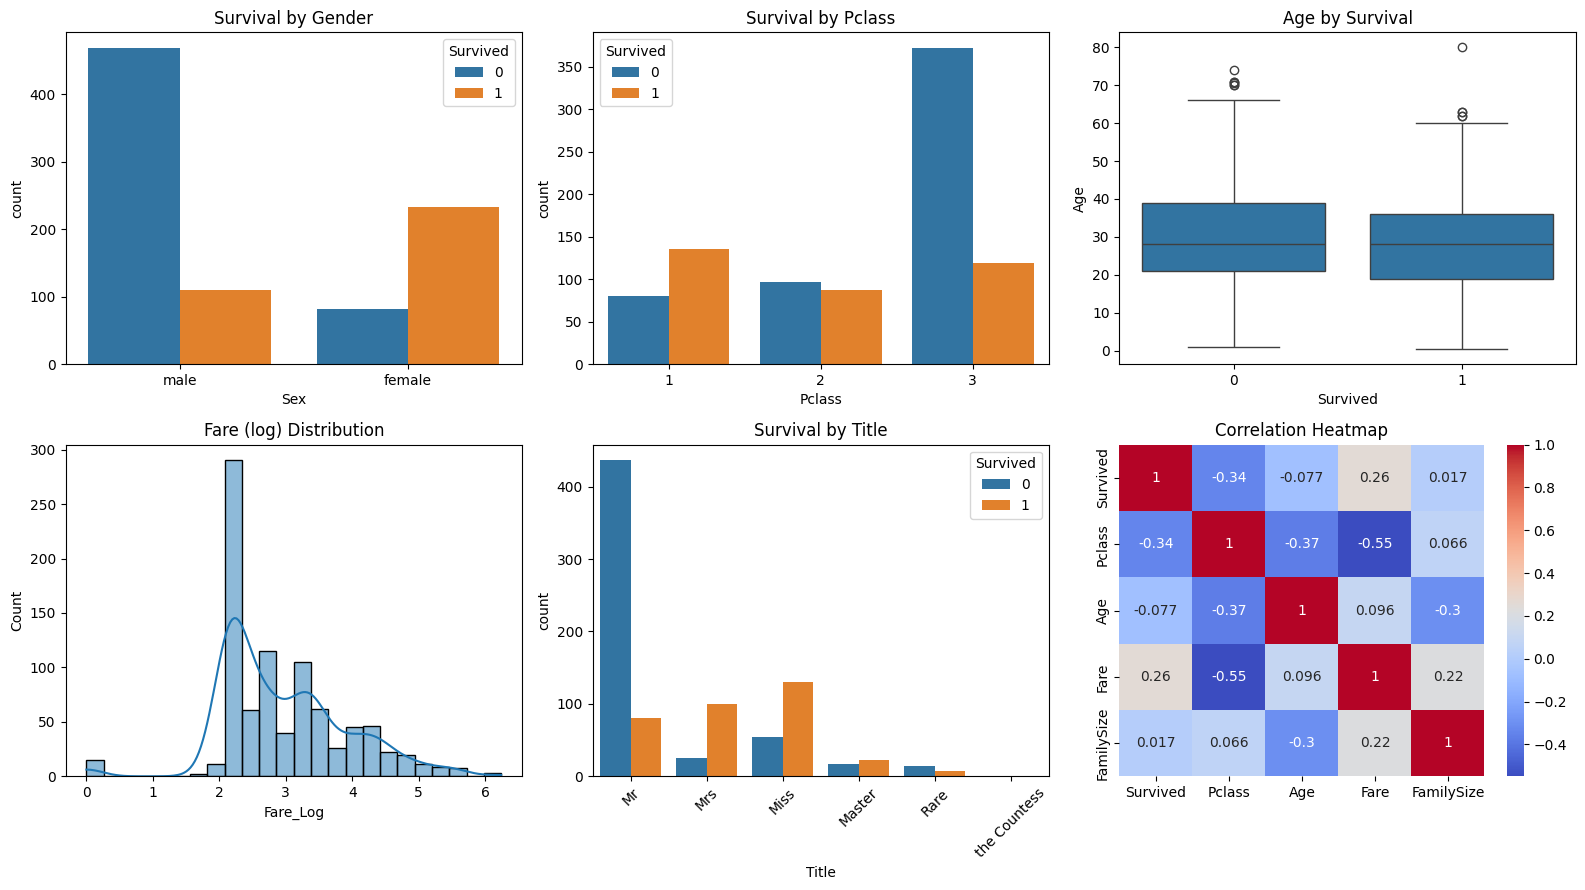

In [13]:
fig, axes = plt.subplots(2,3,figsize=(16,9))

sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0,0])
axes[0,0].set_title('Survival by Gender')

sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Pclass')
 
sns.boxplot(data=df, x='Survived', y='Age', ax=axes[0, 2])
axes[0, 2].set_title('Age by Survival')

sns.histplot(df['Fare_Log'], kde=True, ax=axes[1,0])
axes[1, 0].set_title('Fare (log) Distribution')

sns.countplot(data=df, x='Title', hue='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Survival by Title')
axes[1, 1].tick_params(axis='x', rotation=45)

num_cols = ['Survived', 'Pclass' ,'Age', 'Fare', 'FamilySize']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1,2])
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()